### [참고] Matplotlib.pyplot 에서 출력 문제 설정

In [1]:
# 1. 아래 코드 실행 후, 코랩 재시작
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,859 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122797 files and

In [2]:
# 2. 재시작 후 아래 코드를 실행
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

## 데이터 준비

### 데이터 로딩

In [4]:
import pandas as pd

df = pd.read_csv('/content/sample_data/Molding_Numeric_Data.csv', encoding='cp949')

### 데이터 탐색

In [5]:
# 가독성 향상을 위해 소수점 출력 포맷을 소수점 넷째자리까지 나오도록 설정
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [6]:
df.sample(3)

,LOT NO.,금형상온도,금형하온도,냉각시간,노즐온도,냉각수In 온도_Avg,냉각수In 온도_Std,냉각수Out 온도_Avg,냉각수Out 온도_Std,보압속도,사출압력,사출시간,실린더온도,작동유온도,쿠션량,불량여부
21,22C07,58.3926,61.6748,28.3605,20.6531,27.1077,0.5433,270.4567,1.5178,4.6024,119.3205,4.1042,271.4244,37.8455,3.7606,0
26,22C07,59.1367,62.8485,28.7319,20.6531,27.1077,0.5433,270.4313,1.8547,3.6204,112.0804,3.7646,271.2017,38.6418,3.7289,0
36,22C03,56.8257,61.0429,27.3493,20.6531,27.1077,0.5433,265.6815,1.6633,4.5469,117.3496,4.5113,267.1290,28.0843,4.7454,0


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LOT NO.        100 non-null    object 
 1   금형상온도          100 non-null    float64
 2   금형하온도          100 non-null    float64
 3   냉각시간           100 non-null    float64
 4   노즐온도           100 non-null    float64
 5   냉각수In 온도_Avg   100 non-null    float64
 6   냉각수In 온도_Std   100 non-null    float64
 7   냉각수Out 온도_Avg  100 non-null    float64
 8   냉각수Out 온도_Std  100 non-null    float64
 9   보압속도           100 non-null    float64
 10  사출압력           100 non-null    float64
 11  사출시간           100 non-null    float64
 12  실린더온도          100 non-null    float64
 13  작동유온도          100 non-null    float64
 14  쿠션량            100 non-null    float64
 15  불량여부           100 non-null    int64  
dtypes: float64(14), int64(1), object(1)
memory usage: 12.6+ KB


,금형상온도,금형하온도,냉각시간,노즐온도,냉각수In 온도_Avg,냉각수In 온도_Std,냉각수Out 온도_Avg,냉각수Out 온도_Std,보압속도,사출압력,사출시간,실린더온도,작동유온도,쿠션량,불량여부
count,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
mean,38.2261,44.8870,28.9078,20.7016,27.2411,0.5433,265.8295,3.4323,4.5507,106.8575,2.8003,266.4576,31.8462,2.8017,0.3100
std,12.2748,13.3766,1.8437,0.9266,1.1170,0.2766,8.3441,12.0531,0.5790,28.0154,1.2840,8.4616,4.9506,1.9133,0.4648
min,21.6275,21.9453,22.8005,16.2571,20.9357,0.2374,187.2452,0.1203,0.8591,13.5051,1.4962,188.3993,23.0494,0.1404,0.0000
25%,27.9918,41.8278,28.7591,20.6531,27.1077,0.5433,265.4268,1.3893,4.4472,96.3384,1.7653,265.3925,28.9650,0.9827,0.0000
50%,38.3051,41.8278,29.2085,20.6531,27.1077,0.5433,265.8376,1.5986,4.7637,113.0336,1.9892,267.2178,29.7226,2.4146,0.0000
75%,38.3051,58.1287,29.2085,20.6531,27.1077,0.5433,267.8664,1.7378,4.8308,121.7853,4.1145,269.4608,37.6349,4.4286,1.0000
max,59.6514,63.3119,35.2475,23.2689,30.2775,2.9689,270.9232,109.6399,5.6443,206.0861,4.8901,272.4080,39.5460,9.4090,1.0000


### 상관 관계 분석

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# 의미 없는 데이터인 'LOT NO.' 컬럼을 삭제(drop)
# ☆☆☆☆☆☆☆☆☆☆☆
heatmap_data = df.drop(columns=['LOT NO.'])

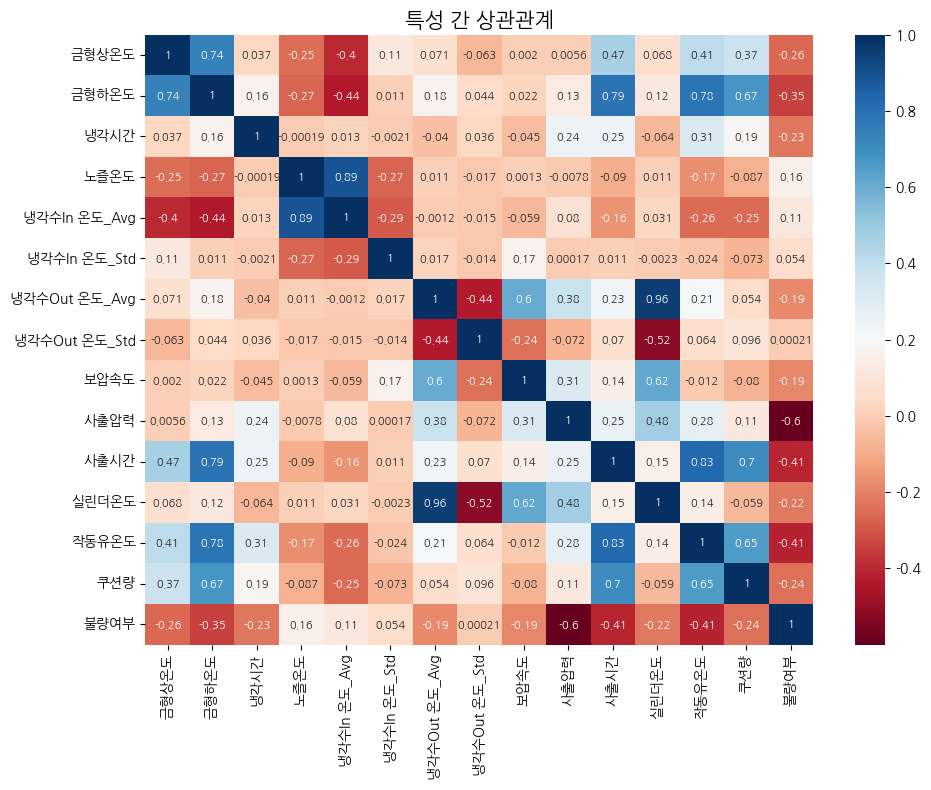

In [40]:
# 상관행렬 시각화
plt.figure(figsize=(10, 8))

plt.title('특성 간 상관관계', size=15)

sns.heatmap(
    heatmap_data.corr(numeric_only=True),
    cmap='RdBu',
    annot=True,
    annot_kws={'size': 8}
)

plt.tight_layout()
plt.show()

### 데이터 분할

In [12]:
from sklearn.model_selection import train_test_split

# 노트북의 새로운 데이터 예제에 나온 공정 변수 14개
feature_cols = [
    '금형상온도',
    '금형하온도',
    '냉각시간',
    '노즐온도',
    '냉각수In 온도_Avg',
    '냉각수In 온도_Std',
    '냉각수Out 온도_Avg',
    '냉각수Out 온도_Std',
    '보압속도',
    '사출압력',
    '사출시간',
    '실린더온도',
    '작동유온도',
    '쿠션량'
]

# 입력 열이 실제 데이터에 있는지 확인
missing_cols = [c for c in feature_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f'CSV에서 찾지 못한 입력 열: {missing_cols}')

# 공정 변수와 Lot 번호를 제외한 열을 정답 후보로 찾기
target_candidates = [
    c for c in df.columns
    if c not in feature_cols + ['LOT NO.']
]

print('정답 열 후보:', target_candidates)

if len(target_candidates) != 1:
    raise ValueError('정답 열을 확정할 수 없습니다. 열 이름 목록을 확인하세요.')

target_col = target_candidates[0]

print('선택한 정답 열:', target_col)
print(df[target_col].value_counts(dropna=False))

# 입력 정보와 정답 나누기
df_X = df[feature_cols].apply(pd.to_numeric, errors='raise')
df_y = df[target_col]

# 정답이 비어 있으면 중단
if df_y.isna().any():
    raise ValueError('정답 열에 빈값이 있습니다.')

# 학습용 80%, 시험용 20%로 나누기
train_X, test_X, train_y, test_y = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    stratify=df_y,
    random_state=42
)

정답 열 후보: ['불량여부']
선택한 정답 열: 불량여부
불량여부
0    69
1    31
Name: count, dtype: int64


### 데이터 표준화

In [13]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 무한대가 있다면 빈값으로 변경
train_X = train_X.replace([np.inf, -np.inf], np.nan)
test_X = test_X.replace([np.inf, -np.inf], np.nan)

# 학습 데이터 전체가 비어 있는 열 확인
if train_X.isna().all().any():
    raise ValueError('학습 데이터에서 모든 값이 비어 있는 열이 있습니다.')

# 학습 데이터의 중앙값으로 빈값 채우기
imputer = SimpleImputer(strategy='median')

trainX_filled = imputer.fit_transform(train_X)
testX_filled = imputer.transform(test_X)

# 표준화
scaler = StandardScaler()

trainX_scaled = scaler.fit_transform(trainX_filled)
testX_scaled = scaler.transform(testX_filled)

## 로지스틱 모델
* 구현해보세요

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 모델 생성
model_logi = LogisticRegression(max_iter=2000)

# 학습
model_logi.fit(trainX_scaled, train_y)

# 예측
pred_logi = model_logi.predict(testX_scaled)

# 결과 확인
print('로지스틱 회귀 혼동행렬')
print(confusion_matrix(test_y, pred_logi))

print(classification_report(test_y, pred_logi, zero_division=0))

로지스틱 회귀 혼동행렬
[[14  0]
 [ 3  3]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.50      0.67         6

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20



## 결정 트리 모델
* 구현해보세요

In [15]:
from sklearn.tree import DecisionTreeClassifier

# 모델 생성
model_tree = DecisionTreeClassifier(random_state=42)

# 학습
model_tree.fit(trainX_scaled, train_y)

# 예측
pred_tree = model_tree.predict(testX_scaled)

# 결과 확인
print('결정 트리 혼동행렬')
print(confusion_matrix(test_y, pred_tree))

print(classification_report(test_y, pred_tree, zero_division=0))

결정 트리 혼동행렬
[[13  1]
 [ 1  5]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.83      0.83      0.83         6

    accuracy                           0.90        20
   macro avg       0.88      0.88      0.88        20
weighted avg       0.90      0.90      0.90        20



## 렌덤 포레스트 모델

#### 학습 및 성능지표 계산

In [16]:
from sklearn.ensemble import RandomForestClassifier

# 랜덤 포레스트 모델 생성
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 모델 학습
rf.fit(trainX_scaled, train_y)


RandomForestClassifier(random_state=42)

In [18]:
# 성능지표
from sklearn.metrics import accuracy_score

# 테스트 데이터 예측
test_pred = rf.predict(testX_scaled)

# 훈련 데이터 예측
train_pred = rf.predict(trainX_scaled)

# 테스트 정확도
test_acc = accuracy_score(test_y, test_pred)

# 훈련 정확도
train_acc = accuracy_score(train_y, train_pred)

print(f"test_accuracy: {test_acc:.4f}")
print(f"train_accuracy: {train_acc:.4f}")

# 불량 검출 성능도 확인
print(classification_report(test_y, test_pred, zero_division=0))

test_accuracy: 0.8500
train_accuracy: 1.0000
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.80      0.67      0.73         6

    accuracy                           0.85        20
   macro avg       0.83      0.80      0.81        20
weighted avg       0.85      0.85      0.85        20



#### 새로운 데이터 입력

In [19]:
# 새로운 데이터의 컬럼명을 학습데이터와 맞추기 위해 데이터의 컬럼명 출력
df.columns

Index(['LOT NO.', '금형상온도', '금형하온도', '냉각시간', '노즐온도', '냉각수In 온도_Avg',
       '냉각수In 온도_Std', '냉각수Out 온도_Avg', '냉각수Out 온도_Std', '보압속도', '사출압력',
       '사출시간', '실린더온도', '작동유온도', '쿠션량', '불량여부'],
      dtype='object')

In [20]:
# 새로운 데이터를 딕셔너리 형태로 입력
new_data = {'금형상온도': [58, 23],
             '금형하온도': [62, 24],
             '냉각시간': [29,29],
             '노즐온도': [20,23],
             '냉각수In 온도_Avg':[27,29],
             '냉각수In 온도_Std':[0.54,0.36],
             '냉각수Out 온도_Avg':[267,265],
             '냉각수Out 온도_Std':[1.5,0.8],
             '보압속도':[4.8,4.9],
             '사출압력':[105,120],
             '사출시간':[4.8,2.1],
             '실린더온도':[268,263],
             '작동유온도':[36,26],
             '쿠션량':[3.5,0.5] }

new_data = pd.DataFrame(new_data)

In [21]:
# 새로운 데이터를 표준화함
new_data_scaled = scaler.transform(new_data)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [37]:
# 새로운 데이터 예측
predicted_result = rf.predict(new_data_scaled)

# 입력 데이터에 예측 결과를 붙여 표로 표시
result_table = new_data.copy()
result_table['불량 여부'] = [
    '불량' if result == 1 else '양품'
    for result in predicted_result
]

display(result_table)

,금형상온도,금형하온도,냉각시간,노즐온도,냉각수In 온도_Avg,냉각수In 온도_Std,냉각수Out 온도_Avg,냉각수Out 온도_Std,보압속도,사출압력,사출시간,실린더온도,작동유온도,쿠션량,불량 여부
0,58,62,29,20,27,0.5400,267,1.5000,4.8000,105,4.8000,268,36,3.5000,양품
1,23,24,29,23,29,0.3600,265,0.8000,4.9000,120,2.1000,263,26,0.5000,불량


In [26]:
for i, result in enumerate(predicted_result, start=1):
    label = {0: '양품', 1: '불량'}.get(result, str(result))
    print(f'{i}번째 데이터: {label}')

1번째 데이터: 양품
2번째 데이터: 불량


#### 특성 중요도

In [27]:
# 특성 중요도 구하기
# ☆☆☆☆☆☆☆☆☆☆☆
# 변수 이름과 중요도를 연결
feature_importances = pd.Series(
    rf.feature_importances_,
    index=feature_cols
)

# 중요도가 높은 순서대로 정렬
feature_importances_sorted = feature_importances.sort_values(
    ascending=False
)

print(feature_importances_sorted)

사출압력            0.3265
작동유온도           0.1460
쿠션량             0.0834
사출시간            0.0716
냉각수Out 온도_Avg   0.0576
보압속도            0.0501
냉각수Out 온도_Std   0.0493
금형하온도           0.0427
실린더온도           0.0404
냉각수In 온도_Avg    0.0297
냉각시간            0.0280
냉각수In 온도_Std    0.0262
노즐온도            0.0245
금형상온도           0.0239
dtype: float64


In [29]:
# 한글 폰트 설치
!apt-get -qq install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 폰트를 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 그래프에 적용
plt.rcParams['font.family'] = fm.FontProperties(
    fname=font_path
).get_name()
plt.rcParams['axes.unicode_minus'] = False

사출압력            0.3270
작동유온도           0.1460
쿠션량             0.0830
사출시간            0.0720
냉각수Out 온도_Avg   0.0580
보압속도            0.0500
냉각수Out 온도_Std   0.0490
금형하온도           0.0430
실린더온도           0.0400
냉각수In 온도_Avg    0.0300
냉각시간            0.0280
냉각수In 온도_Std    0.0260
노즐온도            0.0240
금형상온도           0.0240
dtype: float64


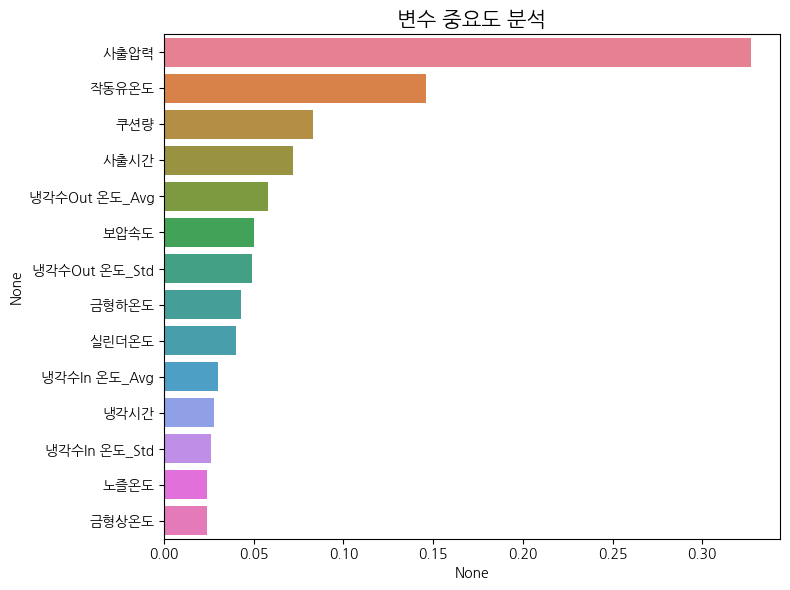

In [35]:
#특성 중요도 시각화
feature_importances = pd.Series(
    rf.feature_importances_.round(3),
    index=train_X.columns
)

feature_importances_sorted = feature_importances.sort_values(
    ascending=False
)

print(feature_importances_sorted)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=feature_importances_sorted,
    y=feature_importances_sorted.index,
    hue=feature_importances_sorted.index,
    legend=False
)

plt.title('변수 중요도 분석', fontsize=15)
plt.tight_layout()
plt.show()

이번 실습에서는 사출성형 공정 데이터를 이용해 로지스틱 회귀, 결정 트리, 랜덤 포레스트의 예측 성능을 비교했다.
새로운 공정 조건을 입력해 양품·불량을 예측하고, 특성 중요도를 통해 모델이 어떤 공정 변수를 판단에 많이 활용했는지 확인했다.
데이터 전처리부터 모델 학습, 평가, 새로운 데이터 예측까지의 전체 과정을 배웠다.